**PROJECT - CUSTOMER CHURN ANALYSIS & PREDITION**

**Summary**

**Customer churn** is when users discontinue a service. For a telecom company, retaining existing customers is far cheaper than finding new ones.

This project is built using the ***Telco Customer Churn dataset by IBM***. It contains detailed information of 7,043 customers, including:

* Demographic info (**gender, age group**)

* Service details (**internet, phone, tech support, streaming**)

* Account details (**contract type, billing, charges**)

And finally, whether they have churned or not.

**Dataset Info**
* Name: WA_Fn-UseC_-Telco-Customer-Churn.csv

* Rows: 7,043 customer records

* Target column: Churn (Yes/No)

**Prediction type: Binary Classification (Will churn or not)**

------------> **Problem Statement**


Can we use the available data to predict if a customer is likely to churn, and if so, why?
How can we help the company take early action to prevent losing such customers?



**TO UPLOAD DATASET**


In [1]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (2).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Collect  and Exploring**

In [3]:
# TO LOAD THE DATASET
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
# Basic structure of the dataset
print("Shape of the dataset (rows, columns):")
print(df.shape)

Shape of the dataset (rows, columns):
(7043, 21)


In [5]:
# Column names in the dataset
print("Column names in the dataset:")
print(df.columns.tolist())

Column names in the dataset:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [6]:
# Data types and non-null values
print(" Data types and non-null values:")
print(df.info())

 Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperless

In [7]:
# First 5 rows
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Streami

In [8]:
# Last 5 rows
print("Last 5 rows of the dataset:")
print(df.tail())

Last 5 rows of the dataset:
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
7038          Yes               Yes             DSL            Yes  ...   
7039          Yes               Yes     Fiber optic             No  ...   
7040           No  No phone service             DSL            Yes  ...   
7041          Yes               Yes     Fiber optic             No  ...   
7042          Yes                No     Fiber optic            Yes  ...   

     DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
7038              Y

In [9]:
# Summary
print(" Summary of numerical columns:")
print(df.describe())

 Summary of numerical columns:
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [10]:
# Checking  missing values
print("Checking for missing values:")
print(df.isnull().sum())

Checking for missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


**Clean and preprocess data**




In [11]:
# Convert 'TotalCharges' to numeric in infor we found it is Object type
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') # errors='coerce' ----- > replaces any invalid text (like " ") with NaN (missing)


In [12]:
# Checking how many values are null
print(df['TotalCharges'].isnull().sum())


11


In [13]:
#  NAN Details ---- CutomerID's
print(df[df['TotalCharges'].isnull()][['customerID','TotalCharges']])

      customerID  TotalCharges
488   4472-LVYGI           NaN
753   3115-CZMZD           NaN
936   5709-LVOEQ           NaN
1082  4367-NUYAO           NaN
1340  1371-DWPAZ           NaN
3331  7644-OMVMY           NaN
3826  3213-VVOLG           NaN
4380  2520-SGTTA           NaN
5218  2923-ARZLG           NaN
6670  4075-WKNIU           NaN
6754  2775-SEFEE           NaN


In [14]:
# To drop that nan values
df = df[df['TotalCharges'].notnull()]


In [15]:
# Again check null values
# Checking how many values are null
print(df['TotalCharges'].isnull().sum())

0


In [16]:
# Checking Data type
df['TotalCharges'].dtype

dtype('float64')

In [17]:
#  Do customers who stay longer actually spend more in total?

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
valid = df[['tenure', 'TotalCharges']].dropna()

tenure = valid['tenure'].to_numpy()
total = valid['TotalCharges'].to_numpy()

corr = np.corrcoef(tenure, total)[0, 1]
print(f"📈 Correlation between tenure and total spending: {corr:.2f}")

📈 Correlation between tenure and total spending: 0.83


In [18]:
#  Who are the top 5% high-paying customers based on monthly charges?

monthly = df['MonthlyCharges'].to_numpy()
threshold = np.percentile(monthly, 95)
outliers = monthly[monthly > threshold]

print(f" Top 5% spenders pay more than: ${threshold:.2f}")
print(f"Number of such customers: {len(outliers)}")


 Top 5% spenders pay more than: $107.42
Number of such customers: 352


In [19]:
#  If 26% of users churn, how much average monthly revenue is lost?

np.random.seed(0)
dropout_mask = np.random.choice([0, 1], size=monthly.shape, p=[0.26, 0.74])
simulated_revenue = monthly * dropout_mask

print(f" Avg monthly revenue with churn: ${np.mean(simulated_revenue):.2f}")
print(f"Original revenue without churn: ${np.mean(monthly):.2f}")

 Avg monthly revenue with churn: $47.60
Original revenue without churn: $64.80


In [20]:
#  Are short-term customers experiencing more variance in monthly charges than long-term ones?

short_term = df[df['tenure'] <= 6]['MonthlyCharges'].to_numpy()
long_term = df[df['tenure'] >= 60]['MonthlyCharges'].to_numpy()

print(" MonthlyCharges Variance:")
print(f"Short-term (≤6 months): {np.var(short_term):.2f}")
print(f"Long-term (≥60 months): {np.var(long_term):.2f}")

 MonthlyCharges Variance:
Short-term (≤6 months): 669.65
Long-term (≥60 months): 1008.62


In [21]:
# Which customers fall into the top 5% when charges are normalized?

normalized = (monthly - np.min(monthly)) / (np.max(monthly) - np.min(monthly))
extreme = df[normalized > 0.95]

print(f" Customers above 95th percentile in charges: {len(extreme)}")
print(extreme[['customerID', 'MonthlyCharges']].head())

 Customers above 95th percentile in charges: 96
     customerID  MonthlyCharges
256  7017-VFHAY          115.10
257  6655-LHBYW          114.35
312  1557-EMYVT          115.05
437  4376-KFVRS          114.05
442  0206-TBWLC          114.65


In [22]:
# Which contract type shows the highest churn rate?

churn_rate = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
print(" Churn Rate by Contract Type (%):")
print((churn_rate['Yes'] * 100).round(2))

 Churn Rate by Contract Type (%):
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Yes, dtype: float64


In [23]:
#  How much revenue is lost on average when a customer churns?

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
avg_loss = df[df['Churn'] == 'Yes']['TotalCharges'].mean()
print(f" Avg revenue lost per churned customer: ${avg_loss:.2f}")


 Avg revenue lost per churned customer: $1531.80


In [24]:
#  Do newer customers churn more compared to older ones?

df['TenureGroup'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 60, 72],
                           labels=['<1yr', '1-2yr', '2-4yr', '4-5yr', '5-6yr'])
tenure_churn = df.groupby('TenureGroup')['Churn'].value_counts(normalize=True).unstack()

print(" Churn by Tenure Group (%):")
print((tenure_churn['Yes'] * 100).round(2))


 Churn by Tenure Group (%):
TenureGroup
<1yr     47.68
1-2yr    28.71
2-4yr    20.39
4-5yr    14.42
5-6yr     6.61
Name: Yes, dtype: float64


/tmp/ipython-input-3050020637.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby('TenureGroup')['Churn'].value_counts(normalize=True).unstack()


In [25]:
#  Do male and female customers churn at different rates?

gender_churn = df.groupby('gender')['Churn'].value_counts(normalize=True).unstack()
print(" Gender-wise Churn Rate (%):")
print((gender_churn['Yes'] * 100).round(2))

 Gender-wise Churn Rate (%):
gender
Female    26.96
Male      26.20
Name: Yes, dtype: float64


In [26]:
#  Which internet service types are associated with higher churn?

internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()
print(" Churn Rate by Internet Service (%):")
print((internet_churn['Yes'] * 100).round(2))


 Churn Rate by Internet Service (%):
InternetService
DSL            19.00
Fiber optic    41.89
No              7.43
Name: Yes, dtype: float64


**Vizuvalization**

 Matplotlib Plots:


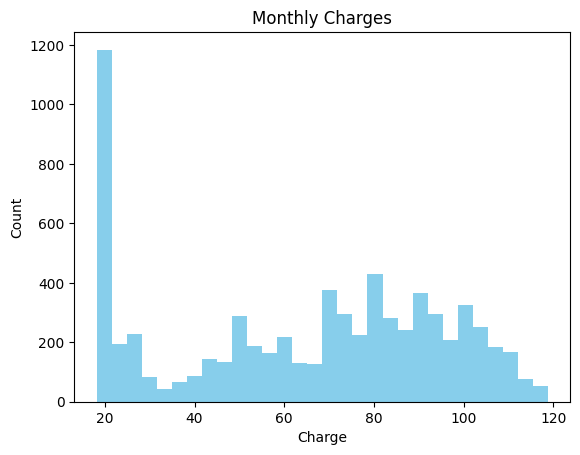

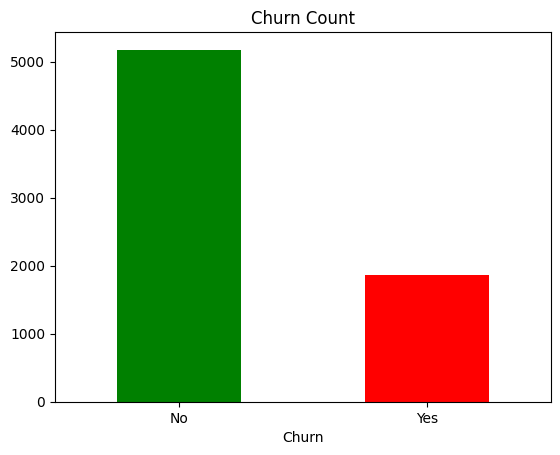

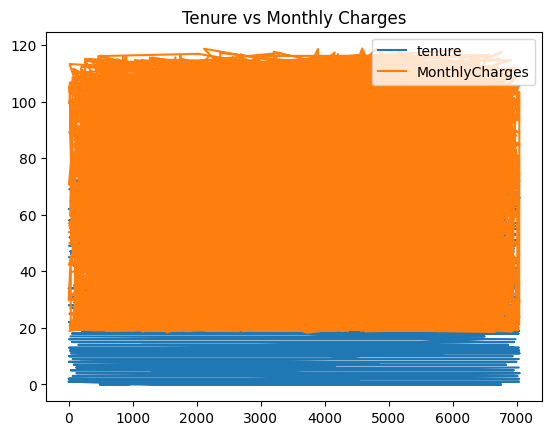

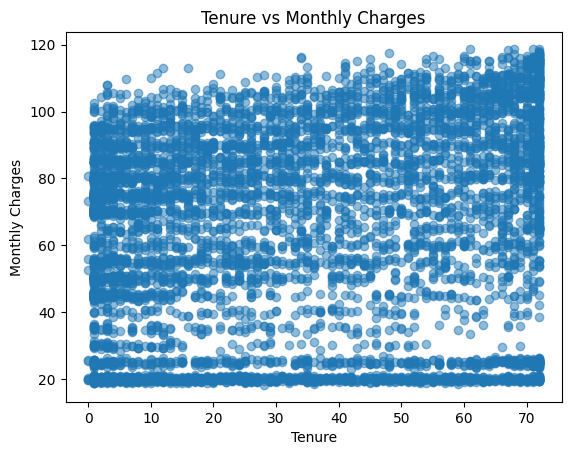

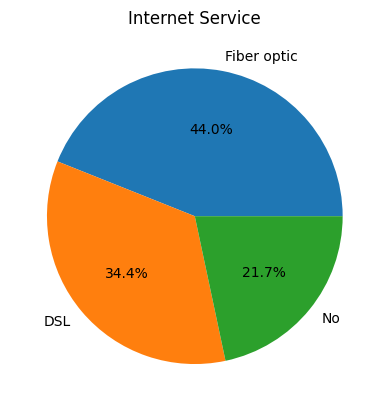

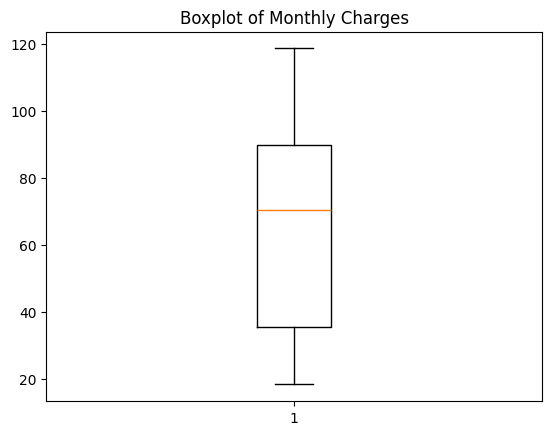

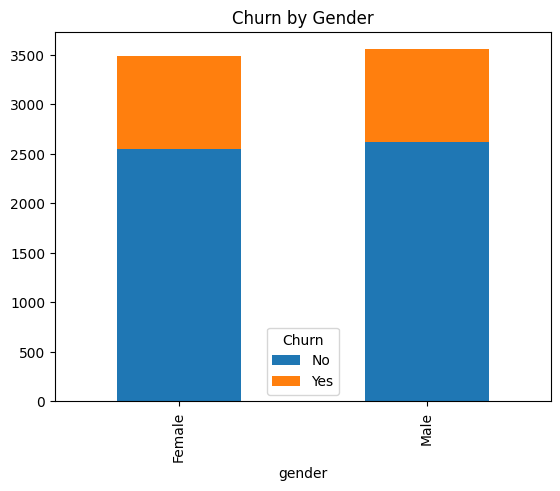

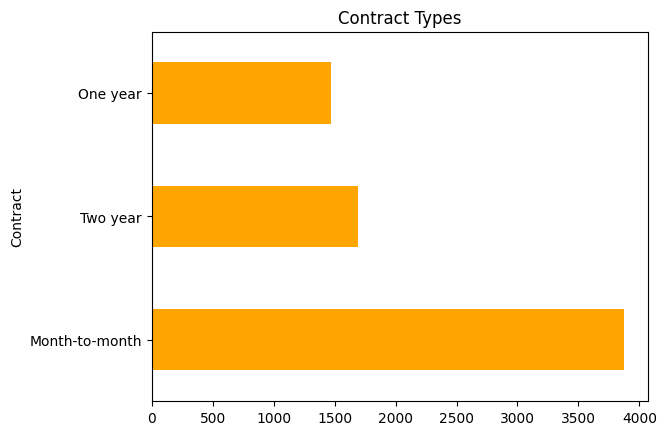

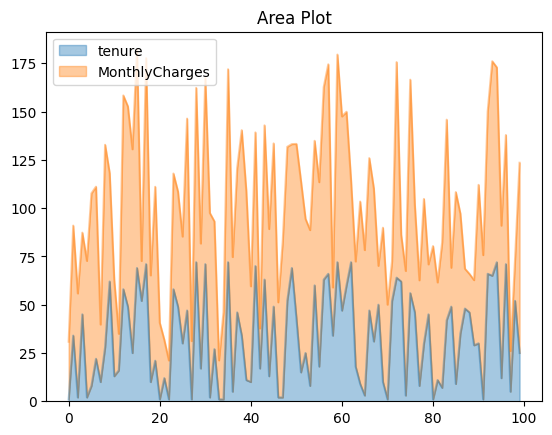

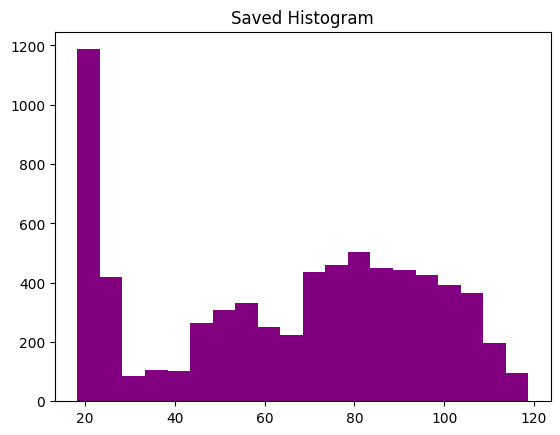

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(" Matplotlib Plots:")

# 1. Histogram
plt.hist(df['MonthlyCharges'], bins=30, color='skyblue')
plt.title('Monthly Charges')
plt.xlabel('Charge')
plt.ylabel('Count')
plt.show()

# 2. Bar plot
df['Churn'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Churn Count')
plt.xticks(rotation=0)
plt.show()

# 3. Line plot
df.sort_values('tenure')[['tenure', 'MonthlyCharges']].plot()
plt.title('Tenure vs Monthly Charges')
plt.show()

# 4. Scatter
plt.scatter(df['tenure'], df['MonthlyCharges'], alpha=0.5)
plt.title('Tenure vs Monthly Charges')
plt.xlabel('Tenure')
plt.ylabel('Monthly Charges')
plt.show()

# 5. Pie
df['InternetService'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Internet Service')
plt.ylabel('')
plt.show()

# 6. Boxplot
plt.boxplot(df['MonthlyCharges'])
plt.title('Boxplot of Monthly Charges')
plt.show()

# 7. Stacked bar
pd.crosstab(df['gender'], df['Churn']).plot(kind='bar', stacked=True)
plt.title('Churn by Gender')
plt.show()

# 8. Horizontal bar
df['Contract'].value_counts().plot(kind='barh', color='orange')
plt.title('Contract Types')
plt.show()

# 9. Area plot
df[['tenure', 'MonthlyCharges']].head(100).plot.area(alpha=0.4)
plt.title('Area Plot')
plt.show()

# 10. Save figure
plt.hist(df['MonthlyCharges'], bins=20, color='purple')
plt.title("Saved Histogram")
plt.savefig("monthly_charges_histogram.png")
plt.show()

Seaborn Visuals:


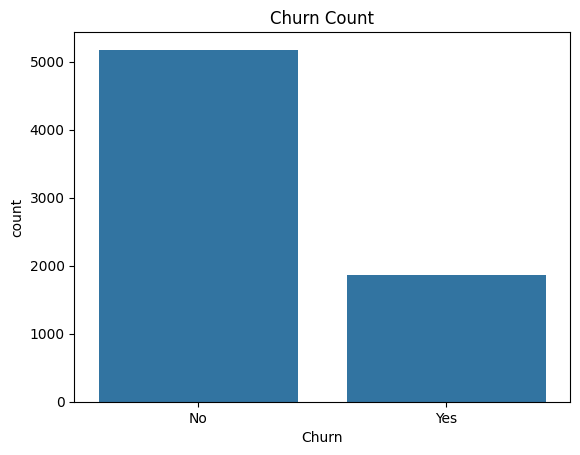

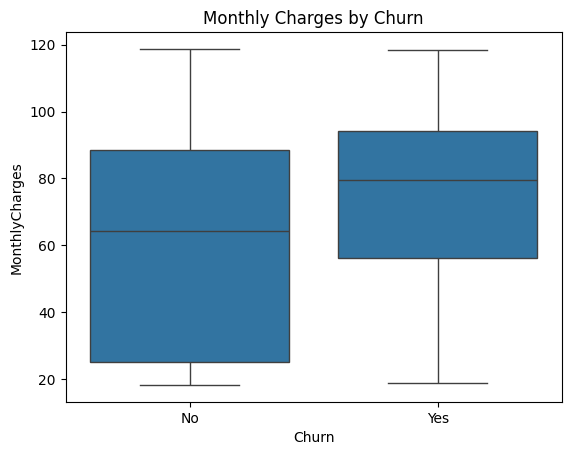

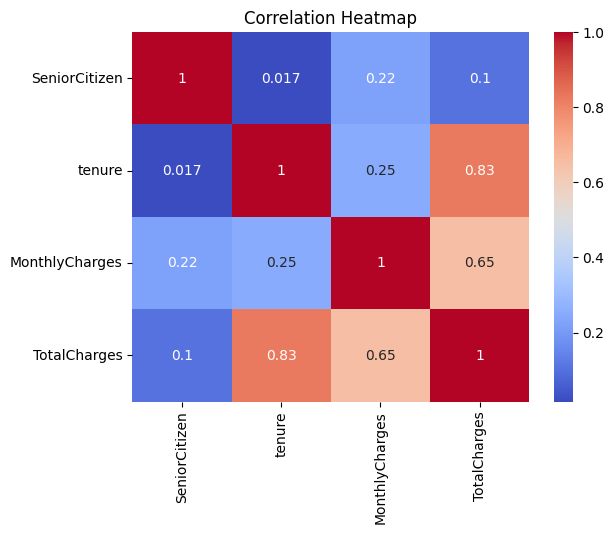

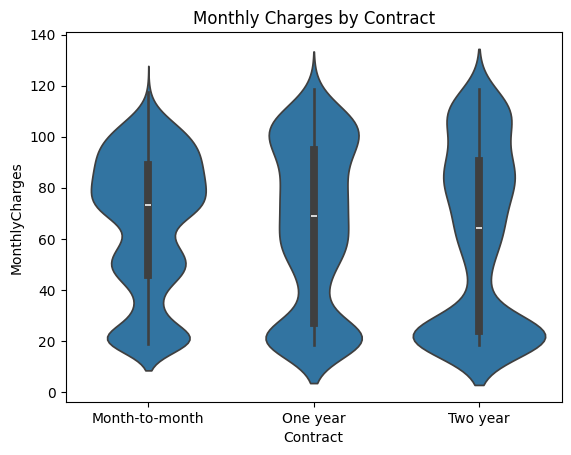

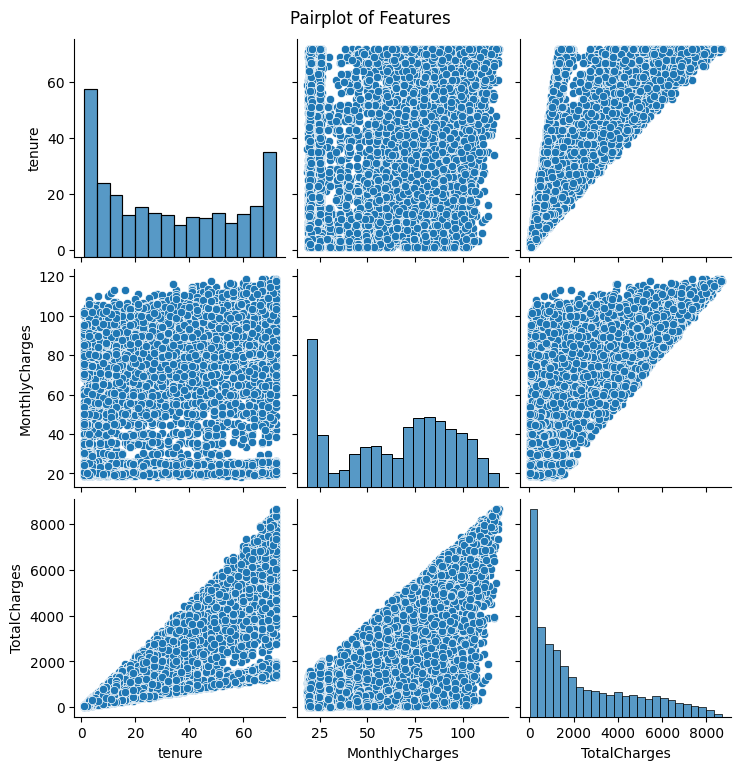

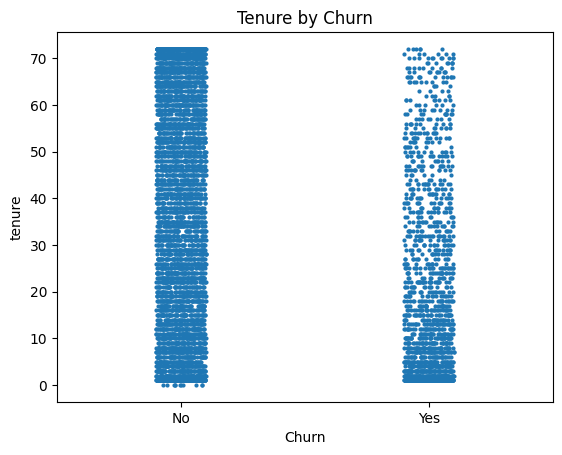

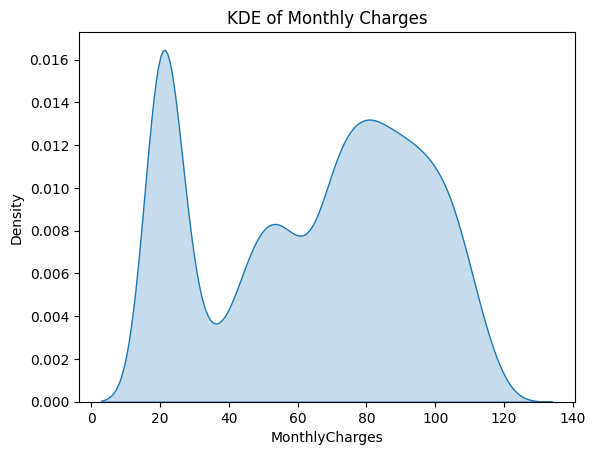

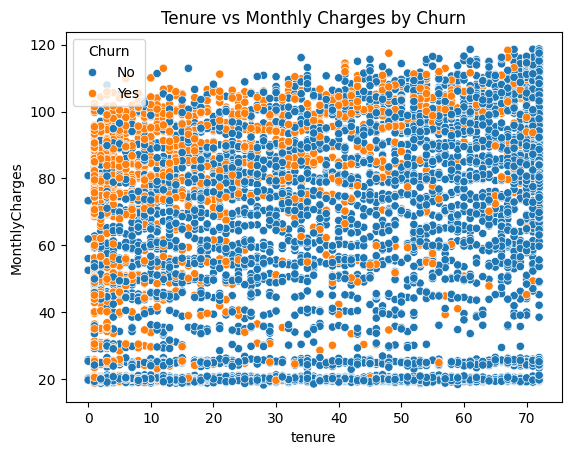

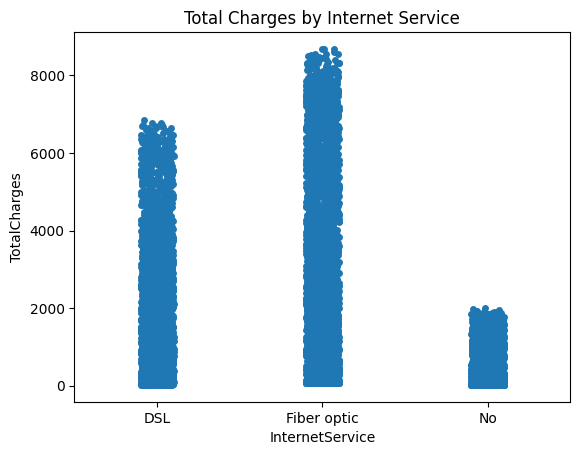

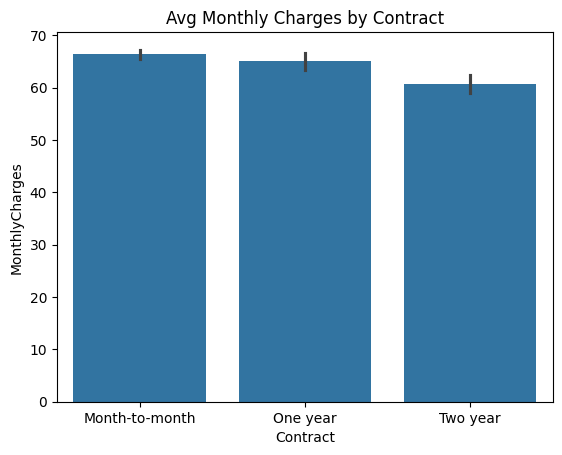

In [28]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Seaborn Visuals:")

# 1. Countplot
sns.countplot(x='Churn', data=df)
plt.title('Churn Count')
plt.show()

# 2. Boxplot
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn')
plt.show()

# 3. Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 4. Violin
sns.violinplot(x='Contract', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Contract')
plt.show()

# 5. Pairplot
sns.pairplot(df[['tenure', 'MonthlyCharges', 'TotalCharges']].dropna())
plt.suptitle('Pairplot of Features', y=1.02)
plt.show()

# 6. Stripplot (instead of swarmplot to avoid overcrowding)
sns.stripplot(x='Churn', y='tenure', data=df, jitter=True, size=3)
plt.title('Tenure by Churn')
plt.show()

# 7. KDE (fixed deprecation warning)
sns.kdeplot(df['MonthlyCharges'], fill=True)
plt.title('KDE of Monthly Charges')
plt.show()

# 8. Scatter with hue
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df)
plt.title('Tenure vs Monthly Charges by Churn')
plt.show()

# 9. Stripplot
sns.stripplot(x='InternetService', y='TotalCharges', data=df, jitter=True)
plt.title('Total Charges by Internet Service')
plt.show()

# 10. Barplot
sns.barplot(x='Contract', y='MonthlyCharges', data=df)
plt.title('Avg Monthly Charges by Contract')
plt.show()

**FEATURE ENGINEERING**


Improving the dataset by creating, modifying, or selecting important features that help the model understand patterns better.


In [29]:
# Remove unnecessary columns which is not usefull for predictin
df.drop(['customerID'], axis=1, inplace=True) # Axis 1 ----> column wise and Inplace = True ----> Directly upate to orginal  df

In [30]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [31]:
# Removing unneccesary spaces from all textv to avoid error
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()


In [32]:
# Convert Churn Column from to Numbers
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


In [33]:
# Converting all categorical values to numberic
df = pd.get_dummies(df, drop_first=True) # pd.get_dummies ---> Convert text into numbers, drop_first=True-----> Avoids extra columns

df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,True,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,0,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,0,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,1,True,True,False,True,False,...,False,False,False,False,False,False,True,False,False,True


**Why ----> One-Hot Encoding (with Drop First Option)**

used get_dummies() because my dataset had many unordered categorical features like PaymentMethod, InternetService, etc., and I needed to convert them into a numerical format suitable for modeling. It’s the most reliable and beginner-friendly method for nominal data."


In [34]:
# To change all bool to int to prededict models
df[df.select_dtypes('bool').columns] = df.select_dtypes('bool').astype(int)
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,1,1,1,1,0,...,0,1,0,1,1,0,1,0,0,1
7039,0,72,103.20,7362.90,0,0,1,1,1,0,...,0,1,0,1,1,0,1,1,0,0
7040,0,11,29.60,346.45,0,0,1,1,0,1,...,0,0,0,0,0,0,1,0,1,0
7041,1,4,74.40,306.60,1,1,1,0,1,0,...,0,0,0,0,0,0,1,0,0,1


In [35]:

# Impact of parameters on churn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

# Load dataset
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Drop customer ID and convert TotalCharges
df.drop('customerID', axis=1, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Encode categorical variables
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Split features and label
X = df.drop('Churn', axis=1)
y = df['Churn']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)

# Get feature importance (coefficients)
importance = model.coef_[0]

# Create DataFrame for better visualization
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': importance,
    'Impact': np.abs(importance)
}).sort_values(by='Impact', ascending=False)

print("📊 Top factors affecting churn:")
print(feature_importance.head(10))

📊 Top factors affecting churn:
             Feature  Coefficient    Impact
4             tenure    -1.408753  1.408753
17    MonthlyCharges     0.693598  0.693598
18      TotalCharges     0.652254  0.652254
14          Contract    -0.584674  0.584674
5       PhoneService    -0.302830  0.302830
8     OnlineSecurity    -0.232233  0.232233
11       TechSupport    -0.225878  0.225878
15  PaperlessBilling     0.180222  0.180222
7    InternetService     0.173775  0.173775
9       OnlineBackup    -0.126089  0.126089


In [36]:

# Model Training and testing for prediction
#  Can we predict customer churn using logistic regression?

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Load dataset
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Drop customer ID and convert TotalCharges to numeric
df.drop('customerID', axis=1, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Encode categorical variables
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Split features and label
X = df.drop('Churn', axis=1)
y = df['Churn']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print(" Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))


 Accuracy: 0.7853589196872779

 Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



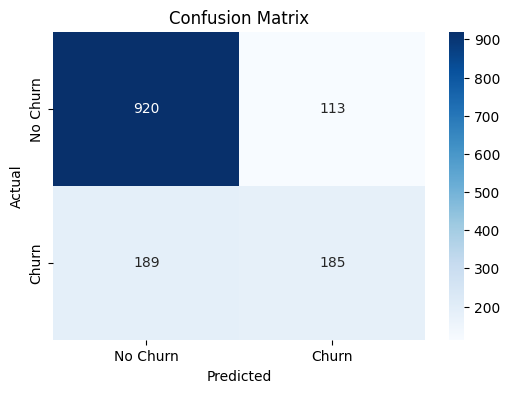

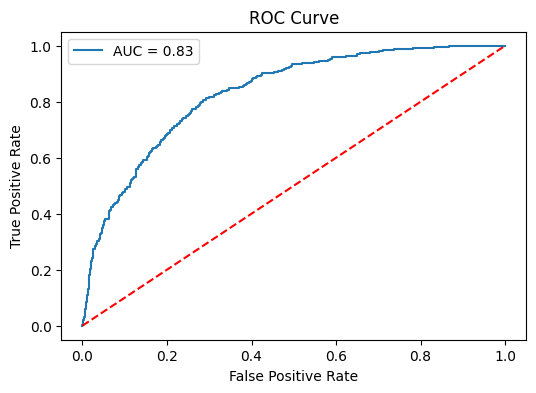

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# ✅ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ✅ ROC Curve
y_pred_prob = model.predict_proba(X_test)[:,1]  # probability of churn
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_prob):.2f}")
plt.plot([0,1], [0,1], linestyle="--", color="red")  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [41]:
print("This project successfully analyzed and predicted customer churn with about 80% accuracy using real telecom data, uncovering key factors that influence customer retention. Thank you to everyone who supported this journey in transforming data into actionable business insights.")

This project successfully analyzed and predicted customer churn with about 80% accuracy using real telecom data, uncovering key factors that influence customer retention. Thank you to everyone who supported this journey in transforming data into actionable business insights.
